# Train & Inference Architecture
In this exercise, you will implement a model with MLP act as both encoder and decoder. The model architecture is like:

```
[Inputs] → [Encoder (MLP)] → [Latent] → [Decoder (MLP)] → [Outputs]
```

In [31]:
# do some setups here
import torch
import torch.nn as nn
import wandb
from floor_plan.model import *
from floor_plan.trainer import *
from floor_plan.data import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data loading
Implement data.py, given a path to our dataset and a condition to filter, load the filtered data.

In [26]:
POINT_DIM = 2 # 2D points like (x, y)
POINTS_PER_ROOM = 8 # we want to select rooms which have 8 points
TRAIN_DATA_PATH = '../Room/train/Room_data.json'
VALIDATE_DATA_PATH = '../Room/val/Room_data.json'

# load the room data
data_train = sample_room_data(get_data(TRAIN_DATA_PATH), POINTS_PER_ROOM)
data_val = sample_room_data(get_data(VALIDATE_DATA_PATH), POINTS_PER_ROOM)

# take a look at them :)
print(f"Train data: {data_train.shape}")
print(f"Train data sample: {data_train[0]}")
print(f"Val data: {data_val.shape}")
print(f"Val data sample: {data_val[0]}")

assert data_train.shape[1] == POINTS_PER_ROOM, "Room points mismatch!"
assert data_train.shape[2] == POINT_DIM, "Point dim mismatch!"

Train data: torch.Size([23919, 8, 2])
Train data sample: tensor([[103.,  86.],
        [119.,  86.],
        [119., 159.],
        [172., 159.],
        [172.,  65.],
        [157.,  65.],
        [157.,  23.],
        [103.,  23.]])
Val data: torch.Size([2533, 8, 2])
Val data sample: tensor([[ 70., 183.],
        [137., 183.],
        [137., 137.],
        [154., 137.],
        [154., 116.],
        [137., 116.],
        [137.,  82.],
        [ 70.,  82.]])


## MLP Encoder and Decoder
Implement `MLPAutoEncoder` in model.py, the model use MLP as both encoder and decoder. In the forward pass, the model takes inputs and compress them into latents, then decode them back to point description.

Once implemented, play with the configs below and run the training.

In [55]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

batch_size = 256
num_steps = 5000
learning_rate = 2e-3 # best trial

config = {
    "d_in": POINTS_PER_ROOM * POINT_DIM,
    "d_model": 8,
    "d_out": POINTS_PER_ROOM * POINT_DIM,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "num_steps": num_steps,
    "optimizer": "AdamW"
}

model = MLPAutoEncoder(
    d_in=config["d_in"],
    d_model=config["d_model"],
    d_out=config["d_out"],
    device=device,
    dtype=torch.float32
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

criterion = nn.MSELoss()

In [56]:
run = wandb.init(
    entity="apeiria0101-shenzhen-university",
    project="floor-plan-autoencoder",
    name="mlp-baseline", # remember to change it for each run
    config=config,
)

train(
    model=model,
    dataset=data_train,
    optimizer=optimizer,
    batch_size=batch_size,
    criterion=criterion,
    device=device,
    num_steps=num_steps,
    print_every=1000,
    run=run
)

run.finish()

{'step   1000 | loss 142.8543 | acc 0.0408 | '}
{'step   2000 | loss 46.8783 | acc 0.1006 | '}
{'step   3000 | loss 6.6049 | acc 0.3147 | '}
{'step   4000 | loss 0.1004 | acc 0.8999 | '}
{'step   5000 | loss 0.0056 | acc 1.0000 | '}


train/acc,▁▁▁▁▁▁▁▁▁▁▁▂▁▁▂▂▂▂▂▂▃▃▃▅▆▆▆▆▆▆▇▇▇▇▇█████
train/loss,█▇▆▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/step,▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇███
train/acc,1
train/loss,0.00557
train/step,4999


Once we have our model trained and you are satisfied, checkpoint (serialize) the model and optimizer into a pth file.

In [57]:

save_checkpoint(model, optimizer, num_steps, f"./checkpoints/checkpoint_{num_steps}.pth")
# and then you can load the checkpoint like:
# iteration = load_checkpoint(model, optimizer, "path-to-checkpoint")

## Evaluate
To evaluate our model's behaviour, we need to test it on evaluate dataset. Implement a `evaluate` function in trainer.py, the fucntion should calculate and return average loss and accuracy on the evaluate dataset.

In [58]:
avg_loss, avg_acc = evaluate(
    model=model,
    dataset=data_val,
    criterion=criterion,
    device=device
)
print(f"average evaluate loss: {avg_loss}")
print(f"average evaluate accuracy: {avg_acc}")

average evaluate loss: 0.07701365649700165
average evaluate accuracy: 0.9991117119789124


## Inference
Before we move on, take a look at our encoded latents, and next we will inplement a inference script to decode the room points from latents.

In [62]:
x = sample_batch(dataset=data_val, num_batches=4)
x_arrange = rearrange(x, "batch seq_len dim -> batch (seq_len dim)", dim=POINT_DIM).to(device)
latents = model.encoder(x_arrange)

print(f"latents: {latents.shape}") # B T
print(f"latents sample: {latents[0]}")

latents: torch.Size([4, 8])
latents sample: tensor([ -98.5852,  309.1753, -188.1232,  206.5428,  -20.4198,   88.7607,
         192.3105, -156.5767], device='cuda:0', grad_fn=<SelectBackward0>)


In [63]:
x_hat = model.decoder(latents)
x_hat = rearrange(x_hat, "batch (seq_len dim) -> batch seq_len dim", dim=POINT_DIM)
x_hat = torch.round(x_hat)

print(f"x_hat sample: {x_hat[0]}")
print(f"x sample: {x[0]}")

x_hat sample: tensor([[145.,  89.],
        [ 75.,  89.],
        [ 75., 143.],
        [199., 143.],
        [199., 118.],
        [170., 118.],
        [170.,  68.],
        [145.,  68.]], device='cuda:0', grad_fn=<SelectBackward0>)
x sample: tensor([[145.,  89.],
        [ 75.,  89.],
        [ 75., 143.],
        [199., 143.],
        [199., 118.],
        [170., 118.],
        [170.,  68.],
        [145.,  68.]])


Now let's visualize the ground truth and predicted room layouts by our model.

In [46]:
import matplotlib.pyplot as plt
import numpy as np

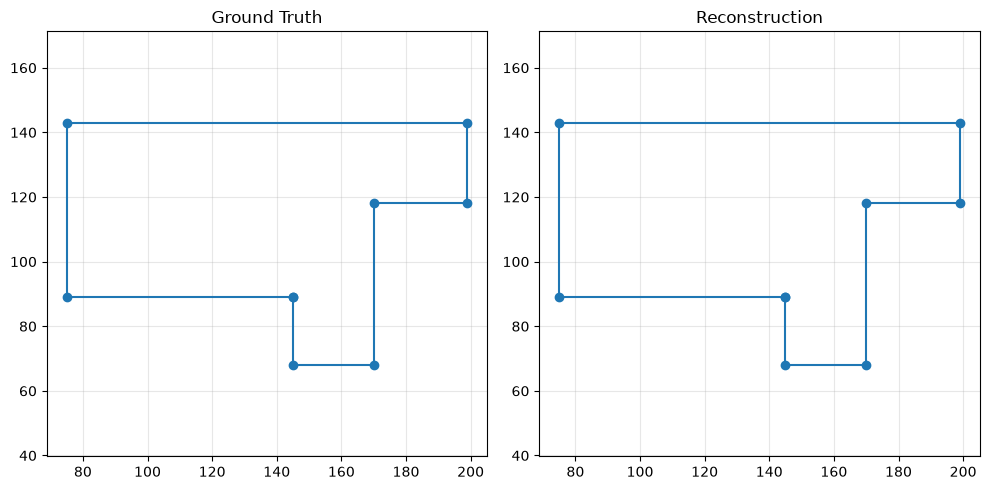

In [64]:
gt = x[0].detach().cpu().numpy()
pred = x_hat[0].detach().cpu().numpy()

gt = np.vstack([gt, gt[0]])
pred = np.vstack([pred, pred[0]])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(gt[:, 0], gt[:, 1], "-o")
axes[0].set_title("Ground Truth")
axes[0].axis("equal")
axes[0].grid(alpha=0.3)

axes[1].plot(pred[:, 0], pred[:, 1], "-o")
axes[1].set_title("Reconstruction")
axes[1].axis("equal")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()